# CESM2-LE IPO Index — Exploration

Plots the **Interdecadal Pacific Oscillation (IPO)** index for a selected CESM2-LE ensemble member.

IPO = Tropical Pacific SSTa − 0.5 × (N.Pacific SSTa + S.Pacific SSTa), following Henley et al. (2015).  
The filtered version uses a 13-year Chebyshev Type-I low-pass filter.

**Plots produced:**
1. Full time series — all months, all years (unfiltered + filtered)
2. Time series for a selected calendar month only
3. SST composite maps for IPO+ and IPO− phases

In [35]:
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
try:
    import cmocean
    CMAP_SST = cmocean.cm.balance
except ImportError:
    CMAP_SST = 'RdBu_r'

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))
from configs import paths

MONTH_LABELS = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
MONTH_NAMES  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

## 1. User Parameters
Edit the cell below before running the notebook.

In [36]:
# ─────────────────────────────────────────────────
# USER PARAMETERS
# ─────────────────────────────────────────────────

ens_member  = 0     # Ensemble member index (0–99)
                    #   0–49  → CMIP6 members
                    #  50–99  → SMBB members

plot_month  = 9     # Calendar month for monthly time-series plot
                    # (1 = Jan, 9 = Sep, 12 = Dec)

# Composite map settings
use_filtered_for_composites = True   # True = 13-yr filtered labels; False = unfiltered
clim_vmin, clim_vmax = -0.5, 0.5    # SST anomaly colorbar limits (K)

# File locations
IPO_FILE  = paths.CESM2LE_DIR / 'climate_indices' / 'cesm2le_ipo_index.nc'
SST_DIR   = paths.CESM2LE_SST_DIR / 'mon'
GRID_FILE = paths.CESM2LE_SST_DIR / 'grid' / 'cesm2le_sst_grid.nc'

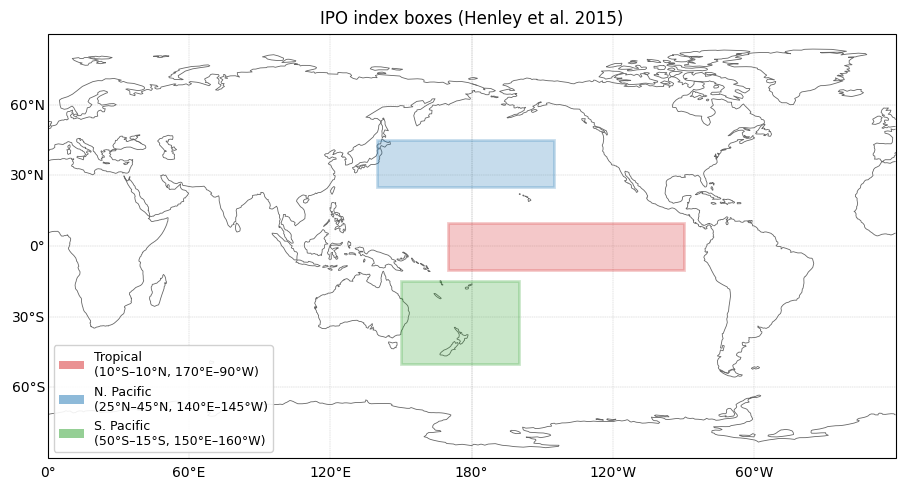

In [37]:
import matplotlib.patches as mpatches

# ── IPO region boxes ────────────────────────────────────────────────────────
#   All coordinates in 0–360°E to match the processing in climate_indices.py
IPO_BOXES = {
    'Tropical\n(10°S–10°N, 170°E–90°W)':    dict(latmin=-10, latmax=10,  lonmin=170, lonmax=270, color='tab:red'),
    'N. Pacific\n(25°N–45°N, 140°E–145°W)': dict(latmin=25,  latmax=45,  lonmin=140, lonmax=215, color='tab:blue'),
    'S. Pacific\n(50°S–15°S, 150°E–160°W)': dict(latmin=-50, latmax=-15, lonmin=150, lonmax=200, color='tab:green'),
}

proj  = ccrs.PlateCarree(central_longitude=180)
trans = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={'projection': proj})
ax.set_global()
ax.coastlines(linewidth=0.6, color='0.4')
ax.set_facecolor('white')

handles = []
for label, b in IPO_BOXES.items():
    rect = mpatches.Rectangle(
        (b['lonmin'], b['latmin']),
        b['lonmax'] - b['lonmin'],
        b['latmax'] - b['latmin'],
        linewidth=2, edgecolor=b['color'], facecolor=b['color'],
        alpha=0.25, transform=trans, zorder=3
    )
    ax.add_patch(rect)
    handles.append(mpatches.Patch(facecolor=b['color'], alpha=0.5, label=label))

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.legend(handles=handles, loc='lower left', fontsize=9, framealpha=0.9)
ax.set_title('IPO index boxes (Henley et al. 2015)', fontsize=12, pad=8)
fig.tight_layout()
plt.show()

## 2. Load IPO Data

In [38]:
ds_ipo = xr.open_dataset(IPO_FILE)
print(ds_ipo)

years = ds_ipo['nyr'].values          # (nyear,)  e.g. array([1990, ..., 2100])
nyear = len(years)

# Full ensemble arrays — shape (nens, nyear, 12)
ipo_unfilt    = ds_ipo['ipo_unfiltered'].values
ipo_filt      = ds_ipo['ipo_filtered'].values
labels_unfilt = ds_ipo['labels'].values
labels_filt   = ds_ipo['labels_filtered'].values

# Select chosen ensemble member
ipo_m   = ipo_unfilt[ens_member]          # (nyear, 12)
ipo_f   = ipo_filt[ens_member]            # (nyear, 12)
lbl_m   = labels_unfilt[ens_member]       # (nyear, 12)
lbl_f   = labels_filt[ens_member]         # (nyear, 12)

# Flatten to 1-D monthly time series
ipo_m_flat = ipo_m.reshape(-1)            # (ntime,)
ipo_f_flat = ipo_f.reshape(-1)
lbl_m_flat = lbl_m.reshape(-1)
lbl_f_flat = lbl_f.reshape(-1)

# Build datetime index
dates = pd.date_range(start=f'{years[0]}-01', periods=nyear * 12, freq='MS')

print(f'\nEnsemble member : {ens_member}')
print(f'Years           : {years[0]}–{years[-1]}  ({nyear} years, {len(dates)} months)')
print(f'IPO+ months (unfilt): {(lbl_m_flat == 1).sum()}')
print(f'IPO- months (unfilt): {(lbl_m_flat == -1).sum()}')
print(f'IPO+ months (filt):   {(lbl_f_flat == 1).sum()}')
print(f'IPO- months (filt):   {(lbl_f_flat == -1).sum()}')

<xarray.Dataset> Size: 4MB
Dimensions:          (nens: 100, nyr: 111, nmon: 12)
Coordinates:
  * nens             (nens) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
  * nyr              (nyr) int64 888B 1990 1991 1992 1993 ... 2098 2099 2100
  * nmon             (nmon) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables:
    ipo_unfiltered   (nens, nyr, nmon) float64 1MB ...
    ipo_filtered     (nens, nyr, nmon) float64 1MB ...
    labels           (nens, nyr, nmon) int64 1MB ...
    labels_filtered  (nens, nyr, nmon) int64 1MB ...
Attributes:
    description:  CESM2-LE IPO index (Henley et al. 2015) and phase labels (i...
    filter:       Chebyshev Type-I low-pass, 13-year cutoff

Ensemble member : 0
Years           : 1990–2100  (111 years, 1332 months)
IPO+ months (unfilt): 672
IPO- months (unfilt): 660
IPO+ months (filt):   689
IPO- months (filt):   643


## 3. Time Series — All Months

Two-panel plot: unfiltered (top) and 13-yr low-pass filtered (bottom).  
Background shading: red = IPO+, blue = IPO−.

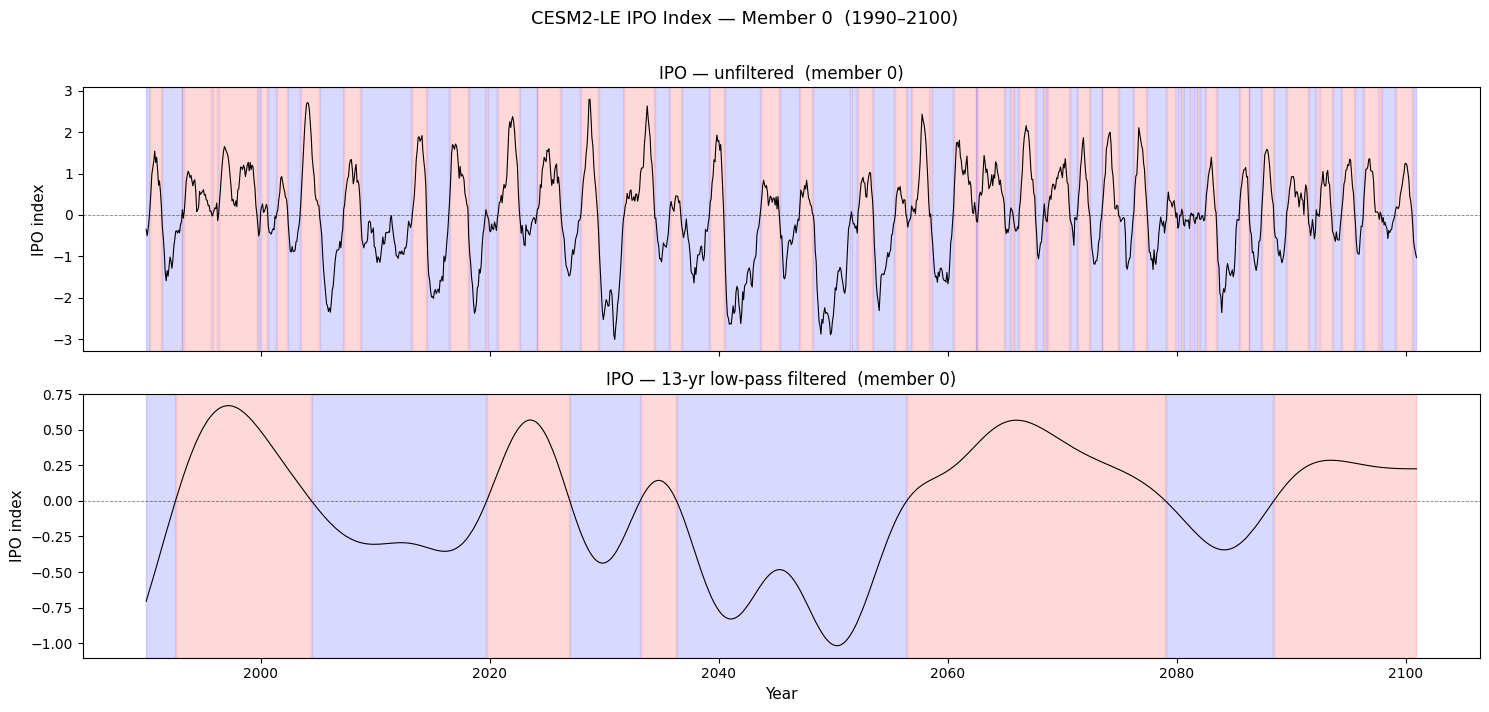

In [39]:
def shade_phases(ax, dates, phases, alpha=0.15):
    """Shade background red (+1) and blue (-1) by phase."""
    start = 0
    for i in range(1, len(phases)):
        if phases[i] != phases[start]:
            if phases[start] != 0:
                color = 'red' if phases[start] == 1 else 'blue'
                ax.axvspan(dates[start], dates[i - 1], color=color, alpha=alpha)
            start = i
    if phases[start] != 0:
        color = 'red' if phases[start] == 1 else 'blue'
        ax.axvspan(dates[start], dates[-1], color=color, alpha=alpha)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

for ax, series, phases, title in [
    (axes[0], ipo_m_flat, lbl_m_flat, 'IPO — unfiltered'),
    (axes[1], ipo_f_flat, lbl_f_flat, 'IPO — 13-yr low-pass filtered'),
]:
    shade_phases(ax, dates, phases)
    ax.plot(dates, series, color='black', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
    ax.set_ylabel('IPO index', fontsize=11)
    ax.set_title(f'{title}  (member {ens_member})', fontsize=12)
    ax.tick_params(labelsize=10)

axes[-1].set_xlabel('Year', fontsize=11)
fig.suptitle(f'CESM2-LE IPO Index — Member {ens_member}  ({years[0]}–{years[-1]})',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Time Series — Selected Month

IPO index for a single calendar month across all years.  
Points are coloured by phase: red = IPO+, blue = IPO−, grey = neutral.

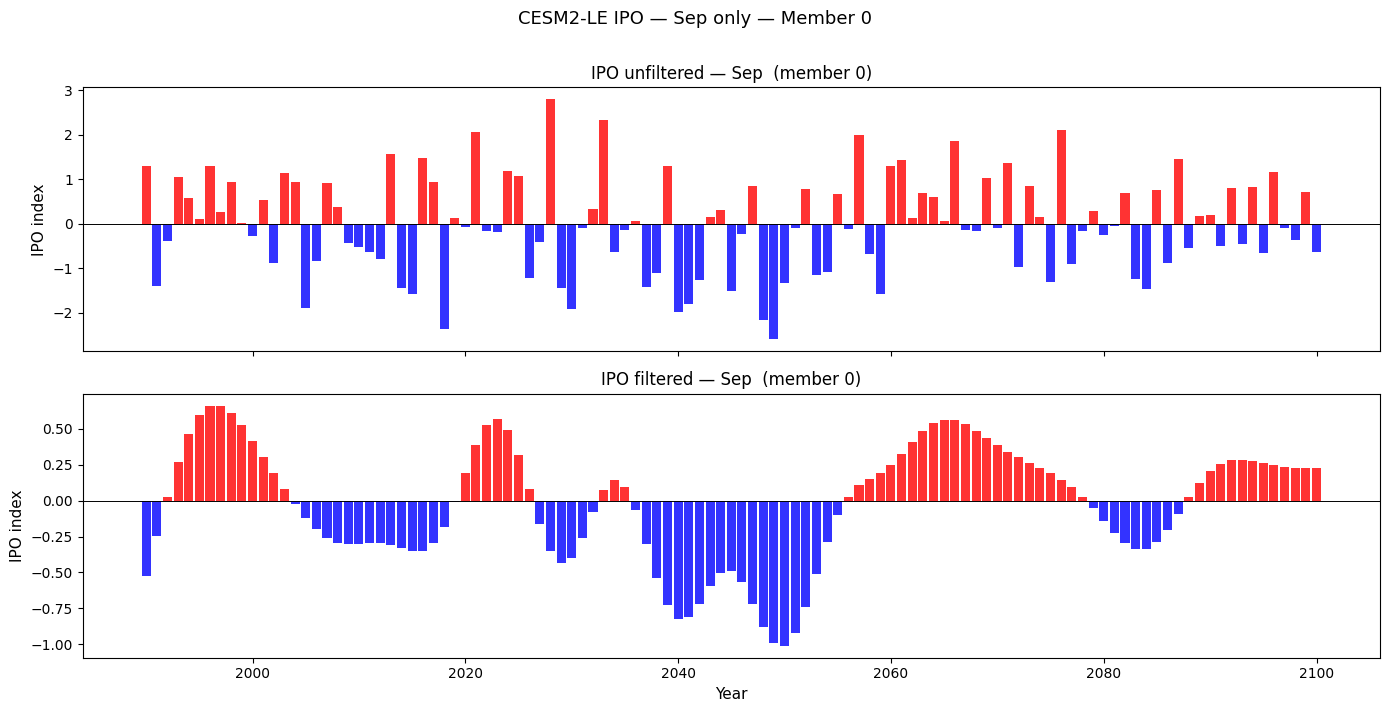

In [40]:
m_idx = plot_month - 1   # 0-based
mon_name = MONTH_NAMES[m_idx]

def phase_colors(phases):
    return ['red' if p == 1 else 'blue' if p == -1 else 'lightgray' for p in phases]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, series_2d, phases_2d, title in [
    (axes[0], ipo_m[:, m_idx], lbl_m[:, m_idx], f'IPO unfiltered — {mon_name}'),
    (axes[1], ipo_f[:, m_idx], lbl_f[:, m_idx], f'IPO filtered — {mon_name}'),
]:
    cols = phase_colors(phases_2d)
    ax.bar(years, series_2d, color=cols, alpha=0.8, width=0.85, edgecolor='none')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_ylabel('IPO index', fontsize=11)
    ax.set_title(f'{title}  (member {ens_member})', fontsize=12)
    ax.tick_params(labelsize=10)

axes[-1].set_xlabel('Year', fontsize=11)
fig.suptitle(f'CESM2-LE IPO — {mon_name} only — Member {ens_member}',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [41]:
# ── Load 2D lat/lon from grid file (TLAT / TLONG) ───────────────────────────
ds_grid = nc.Dataset(str(GRID_FILE), 'r')
ds_grid.set_auto_mask(False)
lat_grid = np.array(ds_grid.variables['TLAT'][:],  dtype=np.float64)   # (nj, ni)
lon_grid = np.array(ds_grid.variables['TLONG'][:], dtype=np.float64)   # (nj, ni)
ds_grid.close()
print(f'lat_grid shape : {lat_grid.shape}   range: [{lat_grid.min():.1f}, {lat_grid.max():.1f}]')
print(f'lon_grid shape : {lon_grid.shape}   range: [{lon_grid.min():.1f}, {lon_grid.max():.1f}]')


lat_grid shape : (192, 288)   range: [-90.0, 90.0]
lon_grid shape : (192, 288)   range: [0.0, 358.8]


In [42]:
def load_member_sst(member_idx, sst_dir):
    """
    Load SST for one ensemble member across all 12 calendar months.
    Returns sst (ntime, nlat, nlon) in chronological order.
    Members 0–49 → first50members files; 50–99 → last50members files.
    """
    if member_idx < 50:
        group, grp_idx = 'first50', member_idx
    else:
        group, grp_idx = 'last50', member_idx - 50

    monthly = []
    for m_label in MONTH_LABELS:
        fpath = sst_dir / f'sst_cesmle_{group}members_mon_{m_label}_199001-210012.nc'
        ds    = nc.Dataset(str(fpath), 'r')
        ds.set_auto_mask(False)
        sst_m = ds.variables['sst_mon'][grp_idx,:,:,:].astype(np.float32)  # (nyear, nlat, nlon)
        ds.close()
        monthly.append(sst_m)
        print(f'  Loaded {m_label}', end='\r')

    print(np.array(monthly).shape)

    # Stack: (nyear, 12, nlat, nlon) → reshape → (ntime, nlat, nlon) chronologically
    sst_stack = np.stack(monthly, axis=1)   # (nyear, 12, nlat, nlon)
    ny, _, nlat, nlon = sst_stack.shape
    sst = sst_stack.reshape(ny * 12, nlat, nlon)
    print(f'  SST loaded: shape {sst.shape}')
    return sst


print(f'Loading SST for member {ens_member}...')
sst = load_member_sst(ens_member, SST_DIR)

sst_clim = np.nanmean(sst, axis=0, keepdims=True)
sst_anom = sst - sst_clim   # (ntime, nlat, nlon)


Loading SST for member 0...
(12, 111, 192, 288)
  SST loaded: shape (1332, 192, 288)


In [43]:
sst_clim = np.nanmean(sst, axis=0, keepdims=True)
sst_anom = sst - sst_clim   # (ntime, nlat, nlon)

# ── Select labels (filtered or unfiltered) based on user parameter ────────────
if use_filtered_for_composites:
    labels_flat = lbl_f_flat   # (ntime,) — 13-yr filtered
    label_desc  = 'filtered'
else:
    labels_flat = lbl_m_flat   # (ntime,) — unfiltered
    label_desc  = 'unfiltered'

# ── Build SST composites ──────────────────────────────────────────────────────
# sst shape: (ntime, nlat, nlon); labels_flat shape: (ntime,)
mask_pos = labels_flat == 1    # IPO+
mask_neg = labels_flat == -1   # IPO−

n_pos = int(mask_pos.sum())
n_neg = int(mask_neg.sum())

sst_pos = np.nanmean(sst_anom[mask_pos], axis=0)   # (nlat, nlon)
sst_neg = np.nanmean(sst_anom[mask_neg], axis=0)   # (nlat, nlon)

print(f'Label type      : {label_desc}')
print(f'IPO+ months     : {n_pos}')
print(f'IPO− months     : {n_neg}')
print(f'Composite shape : {sst_pos.shape}')


Label type      : filtered
IPO+ months     : 689
IPO− months     : 643
Composite shape : (192, 288)


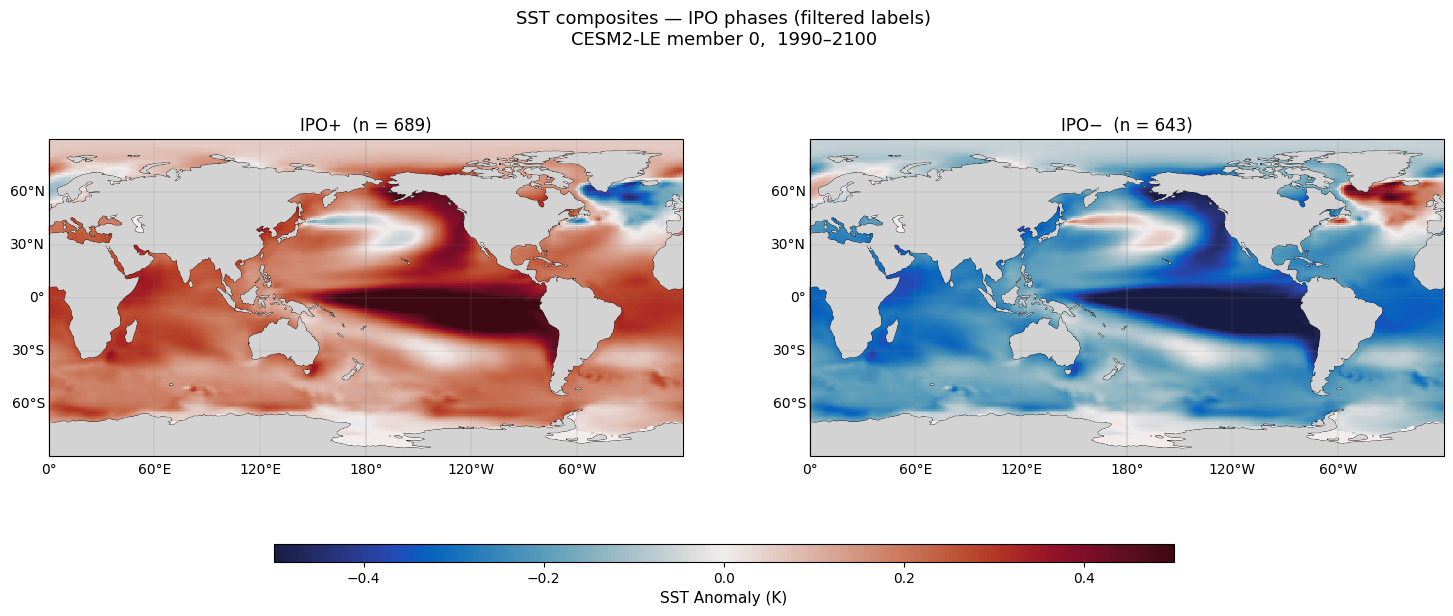

In [44]:
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), subplot_kw={'projection': proj})

for ax, data, title in [
    (axes[0], sst_pos, f'IPO+  (n = {n_pos})'),
    (axes[1], sst_neg, f'IPO−  (n = {n_neg})'),
]:
    ax.set_global()
    ax.coastlines(linewidth=0.5, color='k')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)

    im = ax.pcolormesh(lon_grid, lat_grid, data,
                       cmap=CMAP_SST,
                       vmin=clim_vmin, vmax=clim_vmax,
                       shading='auto',
                       transform=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title, fontsize=12, pad=6)

fig.subplots_adjust(bottom=0.12)
cbar_ax = fig.add_axes([0.25, 0.06, 0.5, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('SST Anomaly (K)', fontsize=11)

fig.suptitle(
    f'SST composites — IPO phases ({label_desc} labels)\n'
    f'CESM2-LE member {ens_member},  {years[0]}–{years[-1]}',
    fontsize=13
)
plt.show()